In [1]:
import pandas as pd

hourly_df = pd.read_csv("../data/processed/hourly_energy.csv")

meter_df = hourly_df[
    hourly_df["meter"] == "BR02"
].copy()

meter_df["x_Timestamp"] = pd.to_datetime(
    meter_df["x_Timestamp"]
)

meter_df = meter_df.sort_values(
    "x_Timestamp"
)

meter_df = meter_df.set_index(
    "x_Timestamp"
)

In [2]:
train_size = int(
    len(meter_df) * 0.9
)

train = meter_df[:train_size]

test = meter_df[train_size:]

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [4]:
model = SARIMAX(
    train["t_kWh"],
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

sarima_model = model.fit()

c:\Users\rithi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\rithi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [5]:
forecast = sarima_model.forecast(
    steps=len(test)
)


In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test["t_kWh"],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test["t_kWh"],
        forecast
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.08738603852517182
RMSE: 0.1360485906316514


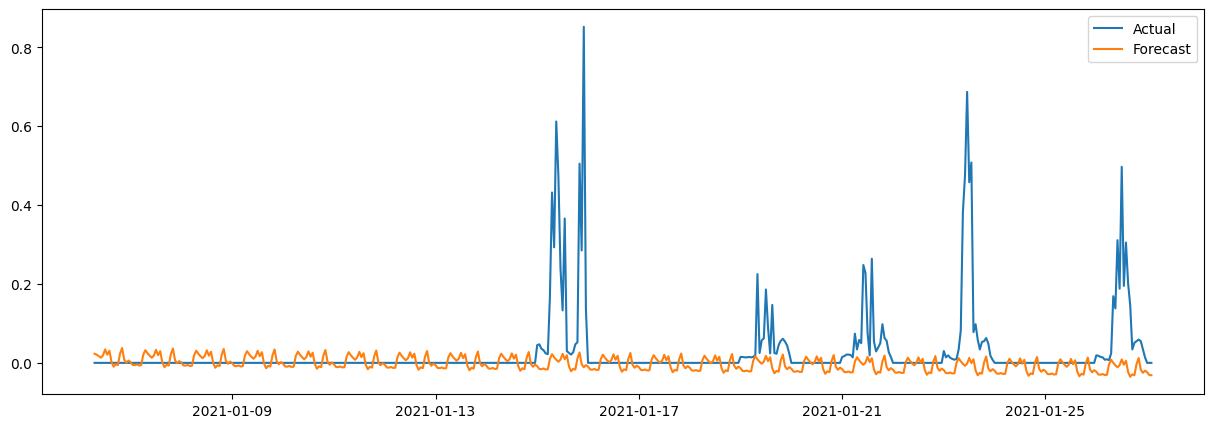

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    test.index[:500],
    test["t_kWh"][:500],
    label="Actual"
)

plt.plot(
    test.index[:500],
    forecast[:500],
    label="Forecast"
)

plt.legend()

plt.savefig(
    "../reports/figures/sarima_forecast.png"
)

plt.show()

In [8]:
results = pd.DataFrame({
    "Model": ["Prophet", "SARIMA"],
    "MAE": [0.2181, 0.0874],
    "RMSE": [0.2685, 0.1360]
})

results

,Model,MAE,RMSE
0,Prophet,0.2181,0.2685
1,SARIMA,0.0874,0.1360


In [9]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)